# Evaluación 2 – Modelado Predictivo de Ingresos Recurrentes



**Integrantes:**
- Amaro Erices – amaro.erices2201@alumnos.ubiobio.cl
- Felipe Faundez – felipe.faundez2301@alumnos.ubiobio.cl
- Massimiliano Caffarena – massimiliano.caffarena2301@alumnos.ubiobio.cl
- Matias Arrepol – matias.arrepol2301@alumnos.ubiobio.cl

## Fase 1: Diagnóstico y Calidad de Datos
En esta sección cargaremos el dataset `clientes_mrr_dataset.csv`, analizaremos la estructura general, calcularemos la presencia de nulos y visualizaremos la distribución de las variables numéricas para detectar outliers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score


# 1. Cargar el dataset
url= ('https://raw.githubusercontent.com/chupetesuazo1/IA/refs/heads/main/E2-IA/clientes_mrr_dataset.csv')
df = pd.read_csv(url)

# Mostrar las primeras filas y estructura
print("--- Estructura General del Dataset ---")
display(df.head())
print(df.info())

--- Estructura General del Dataset ---


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB
None


### 2. Calcular el porcentaje de valores nulos por cada variable

In [ ]:

null_percentage = (df.isnull().sum() / len(df)) * 100
null_summary = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': null_percentage
}).sort_values(by='Porcentaje (%)', ascending=False)

print("--- Porcentaje de Valores Nulos ---")
display(null_summary)

--- Porcentaje de Valores Nulos ---


,Valores Nulos,Porcentaje (%)
satisfaccion_nps,3597,11.990000
tickets_soporte,2464,8.213333
promedio_sesiones_mes,1545,5.150000
sector_empresa,0,0.000000
fecha_registro,0,0.000000
id_cliente,0,0.000000
tamano_empresa,0,0.000000
duracion_contrato,0,0.000000
gasto_mkt_asociado,0,0.000000
pago_puntual,0,0.000000


### Auditoría de Consistencia según Reglas del Diccionario de Datos


In [ ]:
def normalizar_texto(s):
    """Quita espacios, pasa a minúsculas y elimina tildes (Educación -> educacion)."""
    s = s.astype("string").str.strip().str.lower()
    return s.map(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
                 if pd.notna(x) else x)

print("=== AUDITORÍA DE CONSISTENCIA DE DATOS ===\n")

# Validación 1: Formato de id_cliente
formato_correcto = df['id_cliente'].str.match(r'^CLI-\d{4,5}$').all()
print(f"¿Todos los id_cliente cumplen con el patrón 'CLI-XXXX'? {formato_correcto}")
print(f"IDs duplicados: {df['id_cliente'].duplicated().sum()} | Filas duplicadas: {df.duplicated().sum()}\n")

# Validación 2: Categóricas. Se muestran los valores crudos y se comparan,
# ya normalizados, contra el diccionario de datos
validos = {
    'sector_empresa':    {'tecnologia', 'finanzas', 'salud', 'retail', 'educacion'},
    'tamano_empresa':    {'pequena', 'mediana', 'grande'},
    'duracion_contrato': {'mensual', 'anual', '2 anos'},
    'pago_puntual':      {'si', 'no'},
}
for col, esperados in validos.items():
    crudos = df[col].dropna().unique()
    normalizados = set(normalizar_texto(df[col]).dropna().unique())
    invalidos = normalizados - esperados
    print(f"{col}: {len(crudos)} valores crudos -> {len(normalizados)} tras normalizar | "
          f"inválidos: {invalidos if invalidos else 'Ninguno'}")
    if len(crudos) != len(normalizados):
        print(f"   ⚠ Hay variantes de escritura (tildes/mayúsculas/espacios) en {col}: {sorted(crudos)}")

# Validación 3: Rangos numéricos
print(f"\nTickets de soporte negativos: {(df['tickets_soporte'] < 0).sum()}")
nps_fuera = df[(df['satisfaccion_nps'] < 1) | (df['satisfaccion_nps'] > 10)]
print(f"Calificaciones NPS fuera de rango (1-10): {len(nps_fuera)}")

=== AUDITORÍA DE CONSISTENCIA DE DATOS ===

¿Todos los id_cliente cumplen con el patrón 'CLI-XXXX'? True
IDs duplicados: 0 | Filas duplicadas: 0

sector_empresa: 5 valores crudos -> 5 tras normalizar | inválidos: Ninguno
tamano_empresa: 3 valores crudos -> 3 tras normalizar | inválidos: Ninguno
duracion_contrato: 3 valores crudos -> 3 tras normalizar | inválidos: Ninguno
pago_puntual: 2 valores crudos -> 2 tras normalizar | inválidos: Ninguno

Tickets de soporte negativos: 0
Calificaciones NPS fuera de rango (1-10): 0


### Visualización de Outliers y Rangos con diagramas de caja para variables numéricas clave


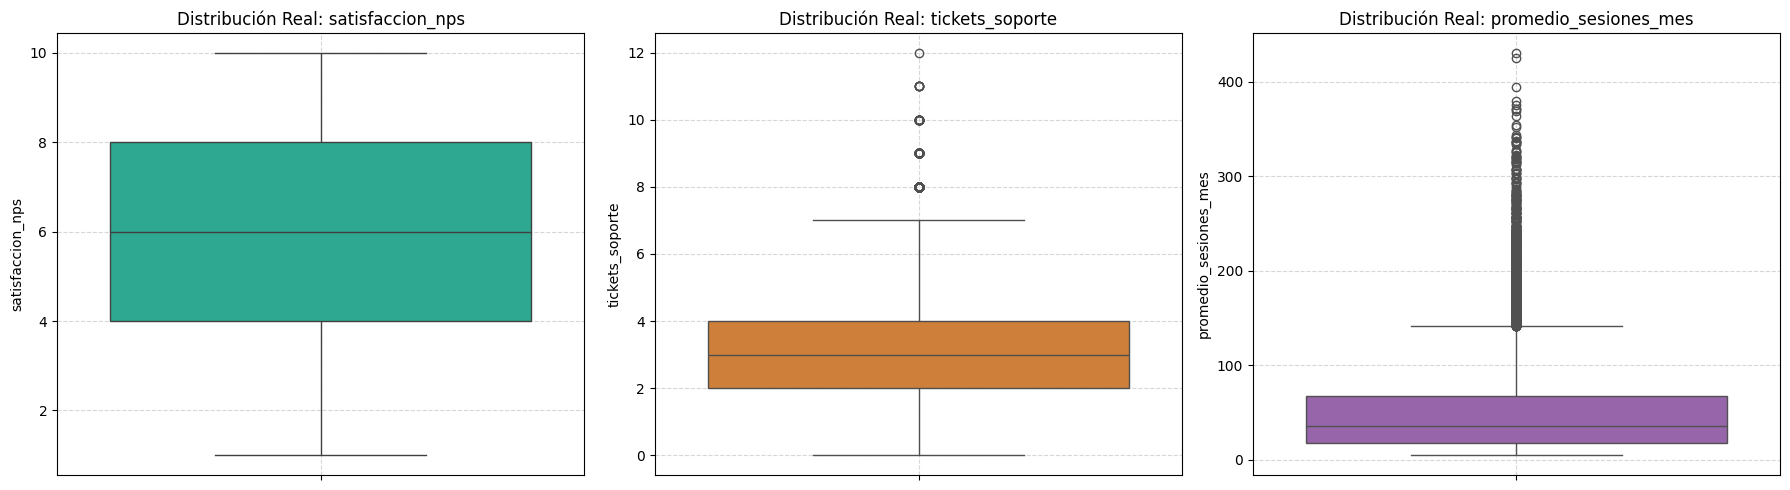

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.boxplot(data=df, y='satisfaccion_nps', ax=axes[0], color='#1abc9c')
axes[0].set_title('Distribución Real: satisfaccion_nps')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.boxplot(data=df, y='tickets_soporte', ax=axes[1], color='#e67e22')
axes[1].set_title('Distribución Real: tickets_soporte')
axes[1].grid(True, linestyle='--', alpha=0.5)

sns.boxplot(data=df, y='promedio_sesiones_mes', ax=axes[2], color='#9b59b6')
axes[2].set_title('Distribución Real: promedio_sesiones_mes')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visualización de la relación entre Gasto de Marketing y MRR Próximo Trimestre
Para evaluar si existe una relación lineal clara entre la inversión en marketing (`gasto_mkt_asociado`) y nuestra variable objetivo (`mrr_proximo_trimestre`), crearemos un gráfico de dispersión con una línea de regresión ajustada.

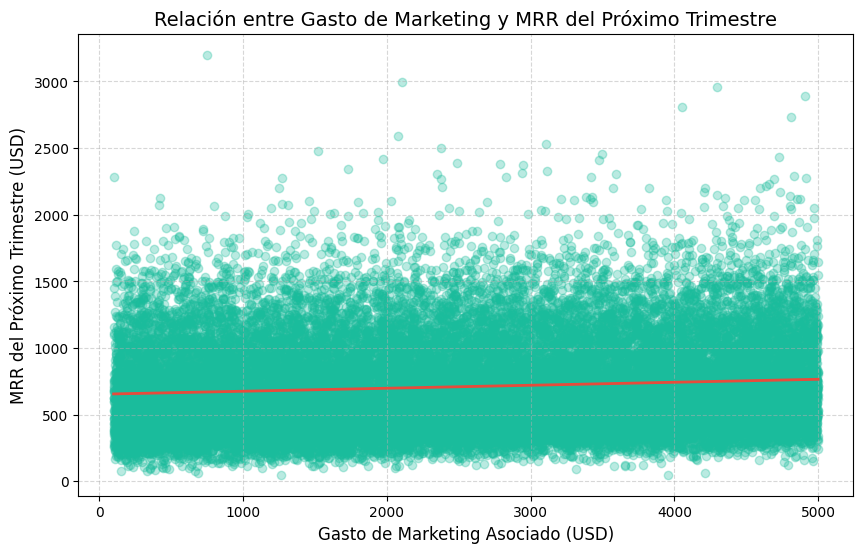

In [ ]:


plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='gasto_mkt_asociado',
    y='mrr_proximo_trimestre',
    scatter_kws={'alpha': 0.3, 'color': '#1abc9c'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

plt.title('Relación entre Gasto de Marketing y MRR del Próximo Trimestre', fontsize=14)
plt.xlabel('Gasto de Marketing Asociado (USD)', fontsize=12)
plt.ylabel('MRR del Próximo Trimestre (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Detección Cuantitativa de Outliers (Valores Atípicos)

Para obtener un recuento exacto de los valores atípicos en cada columna numérica, utilizaremos el método del Rango Intercuartílico (IQR).

**Método IQR:**
1.  **Q1 (Primer Cuartil):** El 25% de los datos están por debajo de este valor.
2.  **Q3 (Tercer Cuartil):** El 75% de los datos están por debajo de este valor.
3.  **IQR (Rango Intercuartílico):** `IQR = Q3 - Q1`.
4.  **Límites para Outliers:**
    *   **Límite Inferior:** `Q1 - 1.5 * IQR`
    *   **Límite Superior:** `Q3 + 1.5 * IQR`

Cualquier valor por debajo del Límite Inferior o por encima del Límite Superior se considera un outlier.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outliers_summary = {}

total_rows = len(df) # Obtener el total de filas para calcular porcentajes

print("--- Conteo y Porcentaje de Valores Atípicos por Columna Numérica (Método IQR) ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Contar outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    percent_outliers = (num_outliers / total_rows) * 100 if total_rows > 0 else 0

    outliers_summary[col] = {'Número de Outliers': num_outliers, 'Porcentaje (%)': percent_outliers}
    print(f"'{col}': {num_outliers} outliers ({percent_outliers:.2f}%)")

# Puedes ver el resumen como un DataFrame si lo deseas
outliers_df = pd.DataFrame.from_dict(outliers_summary, orient='index')
display(outliers_df.sort_values(by='Número de Outliers', ascending=False))

--- Conteo y Porcentaje de Valores Atípicos por Columna Numérica (Método IQR) ---
'tickets_soporte': 328 outliers (1.09%)
'promedio_sesiones_mes': 1367 outliers (4.56%)
'satisfaccion_nps': 0 outliers (0.00%)
'gasto_mkt_asociado': 0 outliers (0.00%)
'mrr_proximo_trimestre': 607 outliers (2.02%)


,Número de Outliers,Porcentaje (%)
promedio_sesiones_mes,1367,4.556667
mrr_proximo_trimestre,607,2.023333
tickets_soporte,328,1.093333
satisfaccion_nps,0,0.000000
gasto_mkt_asociado,0,0.000000


# Fase 2: Limpieza y transformación de datos

Preprocesamiento e ingeniería de características mediante **Pipelines de scikit-learn**.

Para evitar data leakage (fuga de datos), primero se divide el dataset en entrenamiento y prueba, y luego todas las transformaciones que aprenden de los datos (medianas, modas, medias, escalas) se ajustan solo con el conjunto de entrenamiento.

**Nota sobre el diagnóstico (Fase 1):** el EDA se realizó sobre el dataset completo y sirvió para decidir *qué tratamiento* recibe cada variable (por ejemplo, qué escalador usar según sus outliers). Esto es una decisión de diseño, no un parámetro aprendido de los datos, por lo que no genera fuga de información. Los valores numéricos que sí se aprenden (medianas, modas, medias, desviaciones) se calculan únicamente con el conjunto de entrenamiento.

# Ingeniería de características

## Antigüedad del cliente (`antiguedad_dias`)

`fecha_registro` está almacenada como texto. Se convierte a fecha y se calcula la cantidad de días transcurridos hasta una **fecha de referencia fija** (31-dic-2025, la última fecha de registro del dataset). Al ser una operación fila a fila con una constante, no produce fuga de información y puede hacerse antes del split.

## Estandarización de texto
Se normalizan las categóricas (sin espacios, minúsculas y sin tildes) para que variantes como
"Educación" y "Educacion" se traten como la misma categoría y no generen columnas duplicadas en el One-Hot.
Es una operación fila a fila, así que puede hacerse antes del split sin fuga de datos.

In [ ]:
FECHA_REFERENCIA = pd.Timestamp("2025-12-31")

data = df.copy()

# --- Limpieza de texto (operación fila a fila: no genera fuga de datos) ---
cols_categoricas = ["sector_empresa", "tamano_empresa", "duracion_contrato", "pago_puntual"]
for col in cols_categoricas:
    data[col] = normalizar_texto(data[col]).astype(object)

# --- Antigüedad ---
data["fecha_registro"] = pd.to_datetime(data["fecha_registro"])
assert data["fecha_registro"].max() == FECHA_REFERENCIA, "La fecha de referencia no coincide con el último registro"
data["antiguedad_dias"] = (FECHA_REFERENCIA - data["fecha_registro"]).dt.days

print({c: sorted(data[c].dropna().unique()) for c in cols_categoricas})
data[["fecha_registro", "antiguedad_dias"]].head()

{'sector_empresa': ['educacion', 'finanzas', 'retail', 'salud', 'tecnologia'], 'tamano_empresa': ['grande', 'mediana', 'pequena'], 'duracion_contrato': ['2 anos', 'anual', 'mensual'], 'pago_puntual': ['no', 'si']}


,fecha_registro,antiguedad_dias
0,2025-09-14 00:24:49.009633632,107
1,2024-02-12 19:17:24.874829152,687
2,2021-02-03 13:56:48.713623787,1791
3,2021-08-19 03:21:50.803693456,1594
4,2021-09-26 05:21:16.482549416,1556


# Definición de variables dependiente (`y`) e independientes (`X`)

In [ ]:
# Elimina el identificador, la fecha original (ya representada por antiguedad_dias) y la variable objetivo
X = data.drop(columns=["id_cliente", "fecha_registro", "mrr_proximo_trimestre"])
# Variable objetivo
y = data["mrr_proximo_trimestre"]

In [ ]:
# División en Train / Test ANTES de cualquier transformación (Paso clave contra Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}\n")

Dataset de Entrenamiento (X_train): (24000, 9)
Dataset de Prueba (X_test): (6000, 9)



# Definición de Sub-Pipelines por Tipo de Variable

| Grupo | Variables | Imputación | Transformación | Justificación |
| --- | --- | --- | --- | --- |
| A | `gasto_mkt_asociado`,<br>`antiguedad_dias` | Media<br> | `StandardScaler` | Continuas<br>sin outliers |
| B | `promedio_sesiones_mes` | Mediana | `RobustScaler` | ~4.6% de outliers:<br>la mediana y el escalado por mediana/IQR<br>no se distorsionan |
| C | `tickets_soporte` | Moda | `RobustScaler` | Variable de conteo con outliers;<br>la moda conserva valores enteros válidos |
| D | `satisfaccion_nps` | Moda | `StandardScaler` | Escala entera 1–10<br>sin outliers |
| E | `tamano_empresa`,<br>`duracion_contrato`,<br>`pago_puntual` | Moda | `OrdinalEncoder`<br>con orden explícito | Tienen jerarquía<br>(Pequeña < Mediana < Grande;<br>Mensual < Anual < 2 Años)<br>o son binarias (No=0, Si=1) |
| F | `sector_empresa` | Moda | `OneHotEncoder`<br>(`drop="first"`) | Nominal sin orden;<br>`drop="first"` evita multicolinealidad<br>perfecta en la regresión lineal |

### Decisiones de diseño del preprocesamiento

* **Tratamiento de outliers:** los valores atípicos (≈4.6% en `promedio_sesiones_mes`, ≈1.1% en `tickets_soporte`) se **conservan**, porque corresponden a clientes reales de alto uso y no a errores de registro. Se mitigan su efecto con `RobustScaler` (escala por mediana e IQR) y con imputación por mediana, que no se distorsionan con valores extremos.
* **Variables sin escalar:** las ordinales/binarias (`tamano_empresa`, `duracion_contrato`, `pago_puntual`) y las dummies del One-Hot no se escalan, porque ya están en rangos acotados (0–2 o 0–1) y no generan sesgo por diferencia de magnitud.
* **Nota sobre etiquetas:** en el código las categorías aparecen normalizadas (sin tildes ni mayúsculas, por ejemplo `pequena`, `2 anos`).

In [ ]:
# A. Variables numéricas continuas sin outliers severos
num_standard_features = ["gasto_mkt_asociado", "antiguedad_dias"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variable continua con outliers (promedio_sesiones_mes)
num_robust_features = ["promedio_sesiones_mes"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),  # Escalador basado en Mediana e IQR (resistente a outliers)
    ]
)

# C. Variable de conteo con outliers (tickets_soporte)
tickets_features = ["tickets_soporte"]
tickets_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("scaler", RobustScaler()),
    ]
)

# D. Variable discreta sin outliers (satisfaccion_nps)
nps_features = ["satisfaccion_nps"]
nps_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("scaler", StandardScaler()),
    ]
)

# E. Variables categóricas ordinales / binarias
ordinal_features = ["tamano_empresa", "duracion_contrato", "pago_puntual"]
ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    ["pequena", "mediana", "grande"],  # tamano_empresa
                    ["mensual", "anual", "2 anos"],    # duracion_contrato
                    ["no", "si"],                      # pago_puntual
                ],
            ),
        ),
    ]
)

# F. Variable categórica nominal (sector_empresa)
nominal_features = ["sector_empresa"]
nominal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ]
)

## Integración con `ColumnTransformer`

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("tickets", tickets_pipeline, tickets_features),
        ("nps", nps_pipeline, nps_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features),
    ],
    remainder="drop",  # Todas las variables de X están cubiertas por algún sub-pipeline
    verbose_feature_names_out=False,
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['gasto_mkt_asociado', 'antiguedad_dias']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['promedio_sesiones_mes']),
                                ('tickets',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy=...
                                                  OrdinalEncoder(categories=[['pequena',
                                                                              'mediana',
                                                                              'grande'],
                                                                             ['mensual',
                                                                              'anual',
                                                                              '2 '
                                                                              'anos'],
                                                                             ['no',
                                                                              'si']]))]),
                                 ['tamano_empresa', 'duracion_contrato',
                                  'pago_puntual']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['sector_empresa'])],
                  verbose_feature_names_out=False)

# Ajuste y Transformación de Datos (Zero Data Leakage)

In [ ]:
# Fit y Transform solo sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform sobre el conjunto de Prueba (sin FIT)
X_test_processed = preprocessor.transform(X_test)

# Nombres de las columnas procesadas
all_feature_names = list(preprocessor.get_feature_names_out())
all_feature_names

['gasto_mkt_asociado',
 'antiguedad_dias',
 'promedio_sesiones_mes',
 'tickets_soporte',
 'satisfaccion_nps',
 'tamano_empresa',
 'duracion_contrato',
 'pago_puntual',
 'sector_empresa_finanzas',
 'sector_empresa_retail',
 'sector_empresa_salud',
 'sector_empresa_tecnologia']

In [ ]:
X_train_processed.shape, X_test_processed.shape

((24000, 12), (6000, 12))

In [ ]:
# Convertir de nuevo a DataFrame para verificación
X_train_prep = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_prep = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

X_train_prep.head(3)

,gasto_mkt_asociado,antiguedad_dias,promedio_sesiones_mes,tickets_soporte,satisfaccion_nps,tamano_empresa,duracion_contrato,pago_puntual,sector_empresa_finanzas,sector_empresa_retail,sector_empresa_salud,sector_empresa_tecnologia
21753,-0.832517,1.510427,1.087092,-1.0,0.435013,1.0,1.0,1.0,0.0,0.0,0.0,1.0
251,1.537476,0.983769,1.008772,-1.5,-0.020240,1.0,0.0,0.0,0.0,0.0,0.0,1.0
22941,-1.473068,-1.735076,-0.568702,-1.0,0.890265,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Verificación del preprocesamiento

In [ ]:
print("Nulos en X_train_prep:", X_train_prep.isnull().sum().sum())
print("Nulos en X_test_prep :", X_test_prep.isnull().sum().sum())

print("\n--- Valores de imputación aprendidos SOLO con train ---")
print("Mediana promedio_sesiones_mes:", preprocessor.named_transformers_["num_robust"]["imputer"].statistics_)
print("Moda tickets_soporte         :", preprocessor.named_transformers_["tickets"]["imputer"].statistics_)
print("Moda satisfaccion_nps        :", preprocessor.named_transformers_["nps"]["imputer"].statistics_)

print("\n--- Estadísticos de las variables escaladas (train) ---")
cols_escaladas = ["gasto_mkt_asociado", "antiguedad_dias", "promedio_sesiones_mes", "tickets_soporte", "satisfaccion_nps"]
display(X_train_prep[cols_escaladas].describe().round(3))

Nulos en X_train_prep: 0
Nulos en X_test_prep : 0

--- Valores de imputación aprendidos SOLO con train ---
Mediana promedio_sesiones_mes: [36.55652531]
Moda tickets_soporte         : [3.]
Moda satisfaccion_nps        : [7.]

--- Estadísticos de las variables escaladas (train) ---


,gasto_mkt_asociado,antiguedad_dias,promedio_sesiones_mes,tickets_soporte,satisfaccion_nps
count,24000.000,24000.000,24000.000,24000.000,24000.000
mean,0.000,-0.000,0.281,-0.001,0.000
std,1.000,1.000,0.950,0.834,1.000
min,-1.733,-1.735,-0.683,-1.500,-2.297
25%,-0.865,-0.865,-0.378,-0.500,-0.475
50%,0.000,0.002,0.000,0.000,0.435
75%,0.875,0.862,0.622,0.500,0.435
max,1.720,1.735,8.403,4.500,1.801


## Fase 3: Construcción del Modelo

Se entrena una **Regresión Lineal** dentro de un `Pipeline` que une el preprocesamiento y el modelo.
Así, cada vez que se ajusta (incluso dentro de cada fold de la validación cruzada), el imputador,
los escaladores y los encoders se aprenden solo con los datos de entrenamiento de ese fold, evitando data leakage.

In [ ]:

# 1. Construir el Pipeline Unificado
full_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# 2. Validación Cruzada con KFold (Shuffle=True) sobre Train
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(full_pipeline, X_train, y_train, cv=kfold, scoring='r2')
cv_mae_scores = -cross_val_score(full_pipeline, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_error')

print("=== VALIDACIÓN CRUZADA EN ENTRENAMIENTO (5-FOLDS) ===\n")
print(f"R² promedio en CV : {cv_r2_scores.mean():.4f} (± {cv_r2_scores.std():.4f})")
print(f"MAE promedio en CV: ${cv_mae_scores.mean():.2f} USD (± ${cv_mae_scores.std():.2f} USD)\n")

# 3. Entrenar el Pipeline de Extremo a Extremo en el 100% de Entrenamiento
full_pipeline.fit(X_train, y_train)
print("¡Pipeline unificado entrenado con éxito!\n")

# 4. Calcular y Reportar Métricas de Entrenamiento para análisis de sobreajuste
y_train_pred = full_pipeline.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

print("=== MÉTRICAS DE DESEMPEÑO EN ENTRENAMIENTO (TRAIN SET) ===")
print(f"R² de Entrenamiento (R²): {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"MAE de Entrenamiento:     ${mae_train:.2f} USD")

=== VALIDACIÓN CRUZADA EN ENTRENAMIENTO (5-FOLDS) ===

R² promedio en CV : 0.9187 (± 0.0024)
MAE promedio en CV: $69.60 USD (± $1.34 USD)

¡Pipeline unificado entrenado con éxito!

=== MÉTRICAS DE DESEMPEÑO EN ENTRENAMIENTO (TRAIN SET) ===
R² de Entrenamiento (R²): 0.9188 (91.88%)
MAE de Entrenamiento:     $69.56 USD


### Inspección de Parámetros del Modelo

Vamos a visualizar el sesgo o intersección ($w_0$) junto con los coeficientes ($w_i$) asociados a cada una de las variables predictoras del modelo.

In [ ]:
# 1. Extraer el modelo y el preprocesador entrenados desde el Pipeline
model_step = full_pipeline.named_steps['model']

# 2. Obtener la intersección (Bias/w0)
intercept = model_step.intercept_
print(f"Intersección (Bias/w0): {intercept:.4f}\n")

# 3. Asociar cada coeficiente con su respectivo nombre de columna
coef_df = pd.DataFrame({
    'Característica': all_feature_names,
    'Coeficiente (Peso/wi)': model_step.coef_
}).sort_values(by='Coeficiente (Peso/wi)', key=abs, ascending=False)

print("--- Coeficientes del modelo (escalas distintas, no comparables entre sí) ---")
display(coef_df)

Intersección (Bias/w0): 218.2675

--- Coeficientes del modelo (escalas distintas, no comparables entre sí) ---


,Característica,Coeficiente (Peso/wi)
5,tamano_empresa,323.359723
7,pago_puntual,204.336746
2,promedio_sesiones_mes,184.393484
6,duracion_contrato,128.444472
4,satisfaccion_nps,47.941527
3,tickets_soporte,-35.299226
0,gasto_mkt_asociado,32.972837
9,sector_empresa_retail,2.457268
8,sector_empresa_finanzas,0.674504
1,antiguedad_dias,-0.276194


Estos coeficientes representan el cambio esperado en la variable objetivo por cada incremento de una unidad de la variable ya transformada.

## Fase 4: Evaluación e Interpretación de Métricas (Contexto Financiero SaaSFlow)

En esta fase evaluamos el comportamiento de nuestro modelo de regresión lineal sobre el conjunto de prueba (X_test) para medir su capacidad de generalización sobre datos no vistos.

### Objetivos de la Evaluación:
* **Coeficiente de Determinación ($R^2$):** Determina qué proporción de la variabilidad del MRR del próximo trimestre es explicada por nuestro modelo.
* **Error Absoluto Medio (MAE):** Cuantifica la desviación promedio de nuestras predicciones en unidades monetarias reales (USD).

In [ ]:
# 1. Realizar predicciones sobre el conjunto de prueba original usando el Pipeline Unificado
# (El pipeline se encarga de aplicar de forma transparente el .transform() sobre X_test antes de predecir)
y_pred = full_pipeline.predict(X_test)

# 2. Calcular las métricas requeridas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=========================================================")
print("       MÉTRICAS DE RENDIMIENTO (CONJUNTO DE PRUEBA)     ")
print("=========================================================")
print(f" Coeficiente de Determinación (R²): {r2:.4f} ({r2*100:.2f}%)")
print(f" Error Absoluto Medio (MAE):        ${mae:.2f} USD")
print("=========================================================")

       MÉTRICAS DE RENDIMIENTO (CONJUNTO DE PRUEBA)     
 Coeficiente de Determinación (R²): 0.9240 (92.40%)
 Error Absoluto Medio (MAE):        $68.32 USD


### Interpretación financiera de SaaSFlow

* **Coeficiente de Determinación ($R^2$)= 0,9240 (92,40 %):** Significa que el modelo logra explicar aproximadamente el 92,4 % de la variabilidad del MRR del próximo trimestre con las variables utilizadas, el 7,6% restante corresponde a otros factores. Al ser el R² mayor al 90%, el modelo presenta un alto nivel de explicación de la variabilidad de los datos. Para SaaSFlow,  esto permite estimar el comportamiento esperado de sus MRR con una alta proporcion.
* **Error Absoluto Medio (MAE) = $68,32 USD:** Significa que, en promedio, el valor que predice el modelo se equivoca en aproximadamente 68,32 USD por cliente respecto al valor real del MRR. En el contexto financiero de SaaSFlow, este valor permite conocer directamente en dólares cuánto puede desviarse, en promedio, la estimación MRR por cliente.

=== IMPORTANCIA DE LAS VARIABLES (PERMUTATION IMPORTANCE EN TEST) ===


,Característica,Importancia (R² drop),Desviación Estándar
1,tamano_empresa,0.967844,0.018729
3,promedio_sesiones_mes,0.544056,0.007264
5,duracion_contrato,0.130762,0.002265
7,pago_puntual,0.112320,0.001401
4,satisfaccion_nps,0.041583,0.001258
6,gasto_mkt_asociado,0.018261,0.000675
2,tickets_soporte,0.014325,0.000490
0,sector_empresa,0.000010,0.000014
8,antiguedad_dias,-0.000010,0.000005


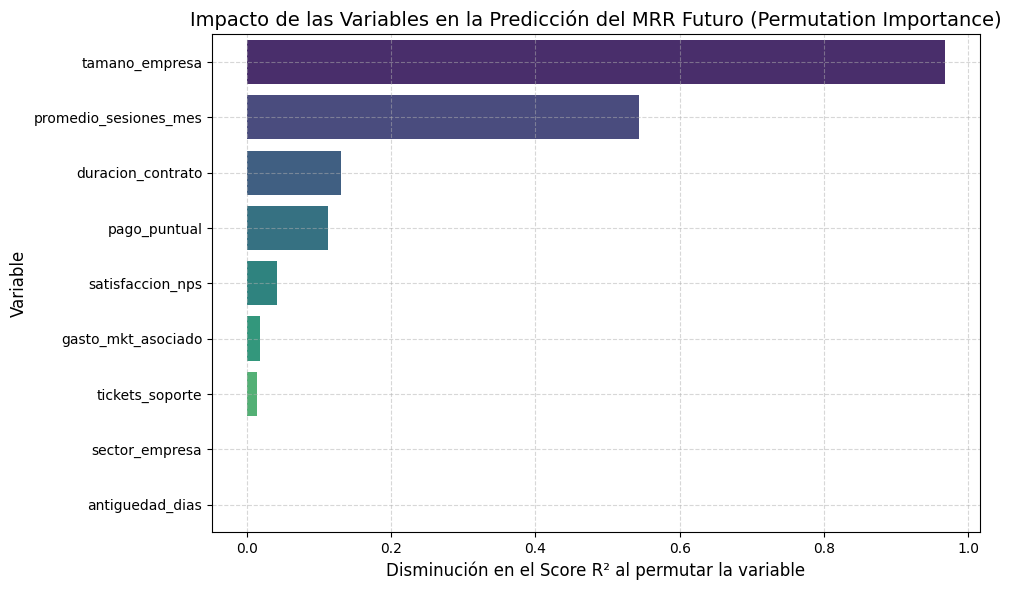

In [ ]:
# 1. Calcular la Importancia por Permutación en el conjunto de prueba
result = permutation_importance(
    full_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Crear un DataFrame con los resultados
importance_df = pd.DataFrame({
    'Característica': X_test.columns,
    'Importancia (R² drop)': result.importances_mean,
    'Desviación Estándar': result.importances_std
}).sort_values(by='Importancia (R² drop)', ascending=False)

print("=== IMPORTANCIA DE LAS VARIABLES (PERMUTATION IMPORTANCE EN TEST) ===")
display(importance_df)

# 2. Graficar las importancias
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia (R² drop)',
    y='Característica',
    data=importance_df,
    palette='viridis',
    hue='Característica',
    legend=False
)
plt.title('Impacto de las Variables en la Predicción del MRR Futuro (Permutation Importance)', fontsize=14)
plt.xlabel('Disminución en el Score R² al permutar la variable', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()